In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# Task # 01

df = pd.read_csv("Dataset/train.csv")

print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

print("\nSummary Statistics:")
display(df.describe())

Shape: (1460, 81)

Data types:
Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

First 5 Rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Summary Statistics:


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [4]:
# Task # 02

target = "SalePrice"

X = df.drop(columns = [target])
y = df[target]

In [5]:
numerical_features = X.select_dtypes(
    include = ["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include = ["object"]
).columns.tolist()


In [6]:
print("Dependent Variable:")
print(target)

print("\nIndependent Variables:")
print(X.columns.tolist())

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nNumber of Independent Variables:", len(X.columns))
print("Number of Numerical Features:", len(numerical_features))
print("Number of Categorical Features:", len(categorical_features))

Dependent Variable:
SalePrice

Independent Variables:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPo

Part 2 — Data Preparation & Train/Test Split

In [7]:
# Task # 04

features = [
    "OverallQual",
    "GrLivArea",
    "TotalBsmtSF",
    "GarageCars",
    "YearBuilt",
    "FullBath",
    "Neighborhood",
    "HouseStyle",
    "KitchenQual",
    "GarageFinish"
]

In [8]:
X = df[features].copy()
y = df["SalePrice"].copy()

categorical_features = [
    "Neighborhood",
    "HouseStyle",
    "KitchenQual",
    "GarageFinish"
]

X = pd.get_dummies(
    X,
    columns = categorical_features,
    drop_first = True,
    dtype = int
)


In [9]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures after encoding:")
print(X.columns.tolist())

print("\nFirst 5 rows of X:")
display(X.head())

print("\nFirst 5 values of y:")
display(y.head())

X shape: (1460, 42)
y shape: (1460,)

Features after encoding:
['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'FullBath', 'Neighborhood_Blueste', 'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr', 'Neighborhood_Crawfor', 'Neighborhood_Edwards', 'Neighborhood_Gilbert', 'Neighborhood_IDOTRR', 'Neighborhood_MeadowV', 'Neighborhood_Mitchel', 'Neighborhood_NAmes', 'Neighborhood_NPkVill', 'Neighborhood_NWAmes', 'Neighborhood_NoRidge', 'Neighborhood_NridgHt', 'Neighborhood_OldTown', 'Neighborhood_SWISU', 'Neighborhood_Sawyer', 'Neighborhood_SawyerW', 'Neighborhood_Somerst', 'Neighborhood_StoneBr', 'Neighborhood_Timber', 'Neighborhood_Veenker', 'HouseStyle_1.5Unf', 'HouseStyle_1Story', 'HouseStyle_2.5Fin', 'HouseStyle_2.5Unf', 'HouseStyle_2Story', 'HouseStyle_SFoyer', 'HouseStyle_SLvl', 'KitchenQual_Fa', 'KitchenQual_Gd', 'KitchenQual_TA', 'GarageFinish_RFn', 'GarageFinish_Unf']

First 5 rows of X:


,OverallQual,GrLivArea,TotalBsmtSF,GarageCars,YearBuilt,FullBath,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,...,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,GarageFinish_RFn,GarageFinish_Unf
0,7,1710,856,2,2003,2,0,0,0,0,...,0,0,1,0,0,0,1,0,1,0
1,6,1262,1262,2,1976,2,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
2,7,1786,920,2,2001,2,0,0,0,0,...,0,0,1,0,0,0,1,0,1,0
3,7,1717,756,3,1915,1,0,0,0,0,...,0,0,1,0,0,0,1,0,0,1
4,8,2198,1145,3,2000,2,0,0,0,0,...,0,0,1,0,0,0,1,0,1,0



First 5 values of y:


0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64

In [10]:
# Task # 05

print("Data Types:")
print(X.dtypes)

print("\nNumber of Non-Numeric Columns:")
print(X.select_dtypes(exclude = ["number"]).shape[1])


Data Types:
OverallQual             int64
GrLivArea               int64
TotalBsmtSF             int64
GarageCars              int64
YearBuilt               int64
FullBath                int64
Neighborhood_Blueste    int64
Neighborhood_BrDale     int64
Neighborhood_BrkSide    int64
Neighborhood_ClearCr    int64
Neighborhood_CollgCr    int64
Neighborhood_Crawfor    int64
Neighborhood_Edwards    int64
Neighborhood_Gilbert    int64
Neighborhood_IDOTRR     int64
Neighborhood_MeadowV    int64
Neighborhood_Mitchel    int64
Neighborhood_NAmes      int64
Neighborhood_NPkVill    int64
Neighborhood_NWAmes     int64
Neighborhood_NoRidge    int64
Neighborhood_NridgHt    int64
Neighborhood_OldTown    int64
Neighborhood_SWISU      int64
Neighborhood_Sawyer     int64
Neighborhood_SawyerW    int64
Neighborhood_Somerst    int64
Neighborhood_StoneBr    int64
Neighborhood_Timber     int64
Neighborhood_Veenker    int64
HouseStyle_1.5Unf       int64
HouseStyle_1Story       int64
HouseStyle_2.5Fin       int6

In [11]:
print("\nTotal Missing Values:")
print(X.isnull().sum().sum())

print("\nMissing Values Per Column:")
print(X.isnull().sum())


Total Missing Values:
0

Missing Values Per Column:
OverallQual             0
GrLivArea               0
TotalBsmtSF             0
GarageCars              0
YearBuilt               0
FullBath                0
Neighborhood_Blueste    0
Neighborhood_BrDale     0
Neighborhood_BrkSide    0
Neighborhood_ClearCr    0
Neighborhood_CollgCr    0
Neighborhood_Crawfor    0
Neighborhood_Edwards    0
Neighborhood_Gilbert    0
Neighborhood_IDOTRR     0
Neighborhood_MeadowV    0
Neighborhood_Mitchel    0
Neighborhood_NAmes      0
Neighborhood_NPkVill    0
Neighborhood_NWAmes     0
Neighborhood_NoRidge    0
Neighborhood_NridgHt    0
Neighborhood_OldTown    0
Neighborhood_SWISU      0
Neighborhood_Sawyer     0
Neighborhood_SawyerW    0
Neighborhood_Somerst    0
Neighborhood_StoneBr    0
Neighborhood_Timber     0
Neighborhood_Veenker    0
HouseStyle_1.5Unf       0
HouseStyle_1Story       0
HouseStyle_2.5Fin       0
HouseStyle_2.5Unf       0
HouseStyle_2Story       0
HouseStyle_SFoyer       0
HouseStyle_

In [12]:
# Task # 06

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

print("X_train shape: ", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_test.shape)

X_train shape:  (1168, 42)
X_test shape:  (292, 42)
y_train shape:  (1168,)
y_test shape:  (292,)


Part 3 — Linear Regression & Predictions

In [13]:
model = LinearRegression()

In [14]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
print("Linear Regression Model trained successfully")

Linear Regression Model trained successfully


In [16]:
# Task # 08

y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

display(comparison.head(10))

,Actual Price,Predicted Price
0,154500,137828.038086
1,325000,318269.765993
2,115000,112411.688554
3,159000,171037.908611
4,315500,316373.104219
5,75500,71835.243909
6,311500,232014.635161
7,146000,145243.692760
8,84500,71507.531364
9,135500,113536.725826


Part 4 — Coefficients & Intercept

In [17]:
# Task # 09

print("Intercept:")
print(model.intercept_)

coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_table["Interpretation"] = coef_table["Coefficient"].apply(
    lambda x: f"For a one-unit increase in this feature, the predicted SalePrice changes by approximately {x:.2f}, holding other features constant."
)

display(coef_table)

Intercept:
-313099.2729540216


,Feature,Coefficient,Interpretation
0,OverallQual,12681.423132,"For a one-unit increase in this feature, the p..."
1,GrLivArea,55.406365,"For a one-unit increase in this feature, the p..."
2,TotalBsmtSF,5.852819,"For a one-unit increase in this feature, the p..."
3,GarageCars,13058.741987,"For a one-unit increase in this feature, the p..."
4,YearBuilt,163.856273,"For a one-unit increase in this feature, the p..."
5,FullBath,-792.577097,"For a one-unit increase in this feature, the p..."
6,Neighborhood_Blueste,-1352.052629,"For a one-unit increase in this feature, the p..."
7,Neighborhood_BrDale,7913.519051,"For a one-unit increase in this feature, the p..."
8,Neighborhood_BrkSide,27303.548057,"For a one-unit increase in this feature, the p..."
9,Neighborhood_ClearCr,57742.759624,"For a one-unit increase in this feature, the p..."


Part 5 — Residuals & Regression Metrics

In [18]:
# Task # 11

residuals = y_test - y_pred

print("First 10 Residuals:")
display(residuals.head(10))

First 10 Residuals:


892     16671.961914
1105     6730.234007
413      2588.311446
522    -12037.908611
1036     -873.104219
614      3664.756091
218     79485.364839
1160      756.307240
649     12992.468636
887     21963.274174
Name: SalePrice, dtype: float64

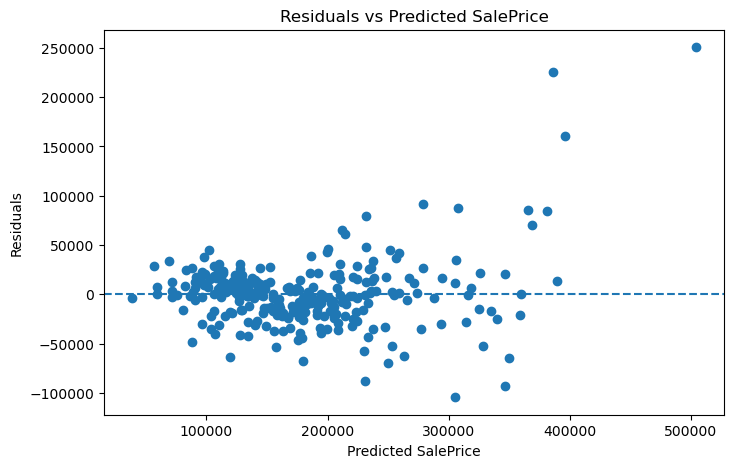

In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted SalePrice")
plt.show()

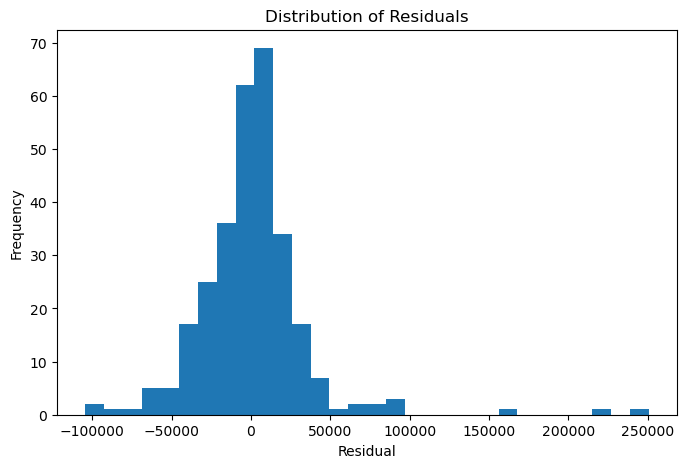

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()

In [21]:
# Task # 12

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metrics_table = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Value": [mae, mse, rmse, r2]
})

display(metrics_table)

,Metric,Value
0,MAE,2.135899e+04
1,MSE,1.207843e+09
2,RMSE,3.475403e+04
3,R²,8.425304e-01


Part 6 — Training vs. Testing & Generalization

In [22]:
# Task 14 — Training vs Testing Performance

train_pred = model.predict(X_train)

train_mae = mean_absolute_error(y_train, train_pred)
train_mse = mean_squared_error(y_train, train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, train_pred)

In [23]:
comparison_table = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Training": [train_mae, train_mse, train_rmse, train_r2],
    "Testing": [mae, mse, rmse, r2]
})

display(comparison_table)

,Metric,Training,Testing
0,MAE,2.058913e+04,2.135899e+04
1,MSE,1.046094e+09,1.207843e+09
2,RMSE,3.234338e+04,3.475403e+04
3,R²,8.246147e-01,8.425304e-01


Part 7 — Final Model Analysis, Conclusion & Kaggle Submission

In [24]:
# Task # 16

coef_analysis = coef_table.copy()

coef_analysis["Absolute Coefficient"] = (
    coef_analysis["Coefficient"].abs()
)

display(
    coef_analysis.sort_values(
        "Absolute Coefficient",
        ascending = False
    ).head(10)
)

,Feature,Coefficient,Interpretation,Absolute Coefficient
20,Neighborhood_NoRidge,82568.762732,"For a one-unit increase in this feature, the p...",82568.762732
27,Neighborhood_StoneBr,68423.025485,"For a one-unit increase in this feature, the p...",68423.025485
21,Neighborhood_NridgHt,64732.594089,"For a one-unit increase in this feature, the p...",64732.594089
29,Neighborhood_Veenker,61902.349198,"For a one-unit increase in this feature, the p...",61902.349198
9,Neighborhood_ClearCr,57742.759624,"For a one-unit increase in this feature, the p...",57742.759624
11,Neighborhood_Crawfor,52726.847881,"For a one-unit increase in this feature, the p...",52726.847881
37,KitchenQual_Fa,-51584.945623,"For a one-unit increase in this feature, the p...",51584.945623
39,KitchenQual_TA,-49835.944229,"For a one-unit increase in this feature, the p...",49835.944229
38,KitchenQual_Gd,-41307.832878,"For a one-unit increase in this feature, the p...",41307.832878
28,Neighborhood_Timber,40613.575601,"For a one-unit increase in this feature, the p...",40613.575601


In [25]:
# Task # 18

test_df = pd.read_csv("Dataset/test.csv")

test_features = test_df[features].copy()

numerical_selected = [
    "OverallQual",
    "GrLivArea",
    "TotalBsmtSF",
    "GarageCars",
    "YearBuilt",
    "FullBath"
]

for col in numerical_selected:
    test_features[col] = test_features[col].fillna(
        X_train[col].median()
    )

for col in categorical_features:
    test_features[col] = test_features[col].fillna("Missing")

test_features = pd.get_dummies(
    test_features,
    columns = categorical_features,
    drop_first = True,
    dtype = int
)

test_features = test_features.reindex(
    columns = X.columns,
    fill_value = 0
)

print("Missing values:", test_features.isnull().sum().sum())
print("Test shape:", test_features.shape)

test_predictions = model.predict(test_features)

submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": test_predictions
})

submission.to_csv("Dataset/submission.csv", index = False)

print("Submission file created successfully.")
print("Submission shape:", submission.shape)

display(submission.head())

Missing values: 0
Test shape: (1459, 42)
Submission file created successfully.
Submission shape: (1459, 2)


,Id,SalePrice
0,1461,108159.214930
1,1462,155484.346664
2,1463,165512.468248
3,1464,185488.994233
4,1465,246344.862592
